# PubQuest Data Exploration / Cleaning

In [51]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf

## Load in data

In [3]:
pq_2009 = pd.read_excel('data/Breweries_Philadelphia_GentrificationStudy.xlsx', sheet_name=0)
pq_2009

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE
0,-75.218824,40.022126,Manayunk Brewery & Restaurant,4120 Main St.,Philadelphia,PA,19127,BrewPub
1,-75.165656,39.949881,Nodding Head Brewery & Restaurant,1516 Sansom St.,Philadelphia,PA,19102,BrewPub
2,-75.136100,39.962594,Yards Brewing Co.,901 N. Delaware Ave.,Philadelphia,PA,19123,MicroBrewery
3,-75.143400,39.948200,Triumph Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub
4,-75.222732,39.947659,Dock Street Brewing Co.,701 S. 50th St.,Philadelphia,PA,19143,BrewPub
5,-75.127752,39.982746,Philadelphia Brewing Co.,2423 Amber St.,Philadelphia,PA,19125,MicroBrewery
6,-75.190340,40.059228,Earth Bread + Brewery,7136 Germantown Ave.,Philadelphia,PA,19119,BrewPub
7,-75.171429,39.962411,Tiedhouse (General Lafayette Brewery),2001 Hamilton St.,Philadelphia,PA,19130,BrewHouse


In [4]:
pq_2015 = pd.read_excel('data/Breweries_Philadelphia_GentrificationStudy.xlsx', sheet_name=1)
pq_2015

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE
0,-75.143400,39.948200,2nd Story Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub
1,-75.108667,39.992811,Do Good Brewing,3245 Amber St.,Philadelphia,PA,19134,Brewery
2,-75.222732,39.947659,Dock Street Brewing Co.,701 S. 50th St.,Philadelphia,PA,19143,BrewPub
3,-75.190340,40.059228,Earth Bread + Brewery,7136 Germantown Ave.,Philadelphia,PA,19119,BrewPub
4,-75.159625,39.948782,Farmers' Cabinet,1113 Walnut St.,Philadelphia,PA,19107,BrewHouse
5,-75.205079,40.075189,Iron Hill Brewery & Restaurant,8400 Germantown Ave.,Philadelphia,PA,19118,BrewPub
6,-75.218824,40.022126,Manayunk Brewery & Restaurant,4120 Main St.,Philadelphia,PA,19127,BrewPub
7,-75.127752,39.982746,Philadelphia Brewing Co.,2423 Amber St.,Philadelphia,PA,19125,Brewery
8,-75.143479,39.977079,Saint Benjamin Brewing Co.,1705 N. 5th Ave.,Philadelphia,PA,19125,Brewery
9,-75.167747,39.904646,Victory Beer Hall,1100 Pattison Ave.,Philadelphia,PA,19148,BrewHouse


In [5]:
pq_2019 = pd.read_excel('data/Breweries_Philadelphia_GentrificationStudy.xlsx', sheet_name=2)
pq_2019

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE
0,-75.143400,39.948200,2nd Story Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub
1,-75.178879,39.923969,Brewery ARS,1927 W. Passyunk Ave.,Philadelphia,PA,19145,Brewery
2,-75.166107,39.966969,Brewery Techne @ Bar Hygge,1720 Fairmount Ave.,Philadelphia,PA,19130,BrewPub
3,-75.202798,40.073763,Chestnut Hill Brewing Co.,8221 Germantown Ave.,Philadelphia,PA,19118,BrewPub
4,-75.180840,39.974457,Crime & Punishment Brewing,2711 W. Girard Ave.,Philadelphia,PA,19130,Brewery
5,-75.108667,39.992811,Do Good Brewing,3245 Amber St.,Philadelphia,PA,19134,Brewery
6,-75.222732,39.947659,Dock Street Brewing Co.,701 S. 50th St.,Philadelphia,PA,19143,BrewPub
7,-75.190340,40.059228,Earth Bread + Brewery,7136 Germantown Ave.,Philadelphia,PA,19119,BrewPub
8,-75.136367,39.975722,Evil Genius Beer Co.,1727 N. Front St.,Philadelphia,PA,19122,BrewPub
9,-75.137708,39.975788,Fermentery Form,1700 N. Palethorpe St.,Philadelphia,PA,19122,Brewery


In [6]:
pq_2023 = pd.read_excel('data/Breweries_Philadelphia_GentrificationStudy.xlsx', sheet_name=3)
pq_2023

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE
0,-75.143400,39.948200,2nd Story Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub
1,-75.161050,40.023150,Attic Brewing Co.,137 W. Berkley St.,Philadelphia,PA,19144,Brewery
2,-75.222730,40.025340,Bald Birds Brewing,4323 Main St.,Philadelphia,PA,19127,BrewHouse
3,-75.178879,39.923969,Brewery ARS,1927 W. Passyunk Ave.,Philadelphia,PA,19145,Brewery
4,-75.128811,39.979929,Brewery ARS,2223 Frankford Ave.,Philadelphia,PA,19125,Brewery
5,-75.166107,39.966969,Brewery Techne @ Bar Hygge,1720 Fairmount Ave.,Philadelphia,PA,19130,BrewPub
6,-75.222732,39.947659,Carbon Copy,701 S. 50th St.,Philadelphia,PA,19143,BrewPub
7,-75.160098,39.932867,Cartesian Brewing Co.,1326 E Passyunk Ave.,Philadelphia,PA,19147,Brewery
8,-75.202798,40.073763,Chestnut Hill Brewing Co.,8221 Germantown Ave.,Philadelphia,PA,19118,BrewPub
9,-75.135520,39.962760,Craft Hall,901 N. Delaware Ave.,Philadelphia,PA,19123,BrewPub


### Concatenate data together and add indicators for what year it's from

Unique ID now becomes NAME x data_year

In [8]:
pq_2009['date_year'] = 2009
pq_2015['date_year'] = 2015
pq_2019['date_year'] = 2019
pq_2023['date_year'] = 2023

pq = pd.concat([pq_2009,pq_2015, pq_2019, pq_2023])
pq

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE,date_year
0,-75.218824,40.022126,Manayunk Brewery & Restaurant,4120 Main St.,Philadelphia,PA,19127,BrewPub,2009
1,-75.165656,39.949881,Nodding Head Brewery & Restaurant,1516 Sansom St.,Philadelphia,PA,19102,BrewPub,2009
2,-75.136100,39.962594,Yards Brewing Co.,901 N. Delaware Ave.,Philadelphia,PA,19123,MicroBrewery,2009
3,-75.143400,39.948200,Triumph Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub,2009
4,-75.222732,39.947659,Dock Street Brewing Co.,701 S. 50th St.,Philadelphia,PA,19143,BrewPub,2009
...,...,...,...,...,...,...,...,...,...
29,-75.153530,39.962110,Triple Bottom Brewing Co.,915 Spring Garden St.,Philadelphia,PA,19123,Brewery,2023
30,-75.140075,39.966742,Urban Village Brewing Co.,1001 N. 2nd St.,Philadelphia,PA,19123,BrewPub,2023
31,-75.167747,39.904646,Victory Beer Hall,1100 Pattison Ave.,Philadelphia,PA,19148,BrewHouse,2023
32,-75.200470,40.013710,Wissahickon Brewing Co.,3705 W. School House Lane,Philadelphia,PA,19129,Brewery,2023


## Geotag

In [33]:
pq_gdf = gpd.GeoDataFrame(pq, 
                          geometry=gpd.points_from_xy(pq.X, pq.Y))

pq_gdf.set_crs(crs="EPSG:4326", inplace=True)

,X,Y,NAME,ADDRESS,CITY,STATE,ZIP,TYPE,date_year,geometry
0,-75.218824,40.022126,Manayunk Brewery & Restaurant,4120 Main St.,Philadelphia,PA,19127,BrewPub,2009,POINT (-75.21882 40.02213)
1,-75.165656,39.949881,Nodding Head Brewery & Restaurant,1516 Sansom St.,Philadelphia,PA,19102,BrewPub,2009,POINT (-75.16566 39.94988)
2,-75.136100,39.962594,Yards Brewing Co.,901 N. Delaware Ave.,Philadelphia,PA,19123,MicroBrewery,2009,POINT (-75.1361 39.96259)
3,-75.143400,39.948200,Triumph Brewing Co.,117 Chestnut St.,Philadelphia,PA,19106,BrewPub,2009,POINT (-75.1434 39.9482)
4,-75.222732,39.947659,Dock Street Brewing Co.,701 S. 50th St.,Philadelphia,PA,19143,BrewPub,2009,POINT (-75.22273 39.94766)
...,...,...,...,...,...,...,...,...,...,...
29,-75.153530,39.962110,Triple Bottom Brewing Co.,915 Spring Garden St.,Philadelphia,PA,19123,Brewery,2023,POINT (-75.15353 39.96211)
30,-75.140075,39.966742,Urban Village Brewing Co.,1001 N. 2nd St.,Philadelphia,PA,19123,BrewPub,2023,POINT (-75.14008 39.96674)
31,-75.167747,39.904646,Victory Beer Hall,1100 Pattison Ave.,Philadelphia,PA,19148,BrewHouse,2023,POINT (-75.16775 39.90465)
32,-75.200470,40.013710,Wissahickon Brewing Co.,3705 W. School House Lane,Philadelphia,PA,19129,Brewery,2023,POINT (-75.20047 40.01371)


In [34]:

pq_gdf = pq_gdf.to_crs(crs="EPSG:2272")

In [35]:
pq_gdf.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [39]:
# export
pq_gdf.to_file('data/all_pq_data.gpkg')

## Join to census tracts w/ demog info

In [44]:
demog_2010 = gpd.read_file("data/tracts_demog_2010.geojson")
demog_2020= gpd.read_file("data/tracts_demog_2020.geojson")

# subsetting to the pre/post period
pq_2009 = pq_gdf[pq_gdf['date_year'] < 2010]
pq_2010s = pq_gdf[(pq_gdf['date_year'] > 2010) & (pq_gdf['date_year'] < 2020)]

pq_2022 = pq_gdf[pq_gdf['date_year'] > 2020]


In [ ]:
demog_2020.crs == pq_2009.crs

True

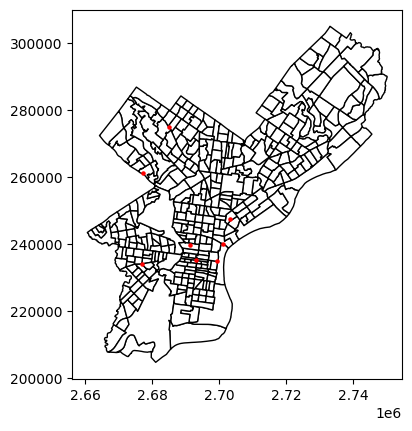

In [45]:
fig, ax = plt.subplots()
demog_2010.plot(ax=ax, color="white", edgecolor="black")
pq_2009.plot(ax=ax, marker='o', color='red', markersize=5)
plt.show()


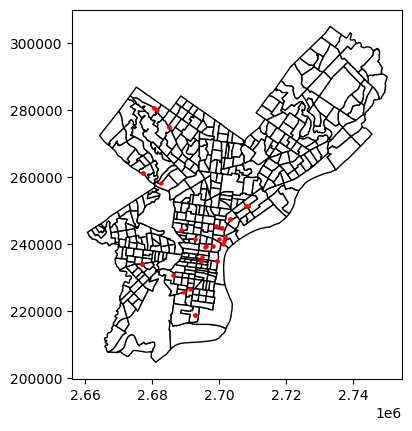

In [46]:
fig, ax = plt.subplots()
demog_2010.plot(ax=ax, color="white", edgecolor="black")
pq_2010s.plot(ax=ax, marker='o', color='red', markersize=5)
plt.show()

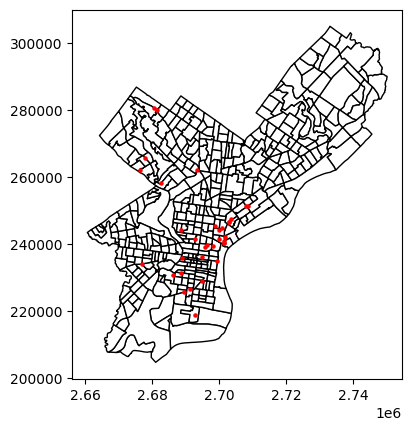

In [47]:
fig, ax = plt.subplots()
demog_2020.plot(ax=ax, color="white", edgecolor="black")
pq_2022.plot(ax=ax, marker='o', color='red', markersize=5)
plt.show()

In [48]:
# outer (left) join to get data at the census tract x brewery level
pq_2009_tracts = gpd.sjoin(demog_2010, pq_2009, how="left", predicate="intersects")
pq_2020_tracts = gpd.sjoin(demog_2020, pq_2022, how="left", predicate="intersects")


In [52]:
# aggregate by census tract to get number of breweries per census tract
# count distinct brewery names
pq_tract_agg09 = pq_2009_tracts.groupby("GEO_ID").agg(
    sum_breweries = ("NAME", "nunique"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    tot_pop = ("tot_pop", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first"),
    geometry = ("geometry", "first")
)

pq_tract_agg09 = gpd.GeoDataFrame(pq_tract_agg09)
pq_tract_agg09.head()

,sum_breweries,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,tot_pop,pct_bachelor_or_higher,gentrified,geometry
GEO_ID,,,,,,,,,,
42101000100,0,0.063830,0.125359,0.036228,354800.0,73041.0,3478.0,72.3,0,"POLYGON ((2699720.168 236062.074, 2699714.353 ..."
42101000200,0,0.102826,1.280899,0.026898,254700.0,43218.0,2937.0,33.3,0,"POLYGON ((2693798.32 238055.129, 2693801.453 2..."
42101000300,0,0.107920,0.244241,0.042600,456000.0,65577.0,3169.0,68.8,0,"POLYGON ((2689340.17 238711.684, 2689558.413 2..."
42101000401,0,0.186353,0.525176,0.050353,429600.0,21832.0,2125.0,71.5,0,"POLYGON ((2690855.839 236871.741, 2690852.497 ..."
42101000402,0,0.056652,0.243794,0.034691,152800.0,50020.0,3142.0,58.9,0,"POLYGON ((2693576.749 236476.085, 2693556.196 ..."


### TODO: Join 2009 aggregated data with 2020 data ??

## 2009 models

TODO: REPLACE GENTRIFICATION DECOMPOSITION WITH 2020 CENSUS DATA
- Need to match census tracts

In [59]:
gent_2009_mod = smf.logit(" gentrified~ sum_breweries + prop_black+prop_asian+prop_hispanic_or_latino + med_inc + med_prop_val + pct_bachelor_or_higher",
                 data=pq_tract_agg09).fit()

gent_2009_mod.summary()

Optimization terminated successfully.
         Current function value: 0.290155
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  367
Model:                          Logit   Df Residuals:                      359
Method:                           MLE   Df Model:                            7
Date:                Fri, 29 May 2026   Pseudo R-squ.:                 0.07824
Time:                        10:42:00   Log-Likelihood:                -106.49
converged:                       True   LL-Null:                       -115.53
Covariance Type:            nonrobust   LLR p-value:                   0.01162
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.8941      1.063      0.841      0.400      -1.189       2.977
sum_breweries               1.1779      0.994      1.185      0.236      -0.771       3.126
prop_black                 -2.0648      0.824     -2.507      0.012      -3.679      -0.450
prop_asian                  1.1192      1.014      1.104      0.270      -0.868       3.106
prop_hispanic_or_latino    -3.0960      1.550     -1.997      0.046      -6.135      -0.057
med_inc                 -4.387e-05   1.71e-05     -2.561      0.010   -7.74e-05   -1.03e-05
med_prop_val            -5.919e-06   4.02e-06     -1.472      0.141   -1.38e-05    1.96e-06
pct_bachelor_or_higher      0.0164      0.019      0.881      0.378      -0.020       0.053
===========================================================================================
"""

In [56]:
prop_val_2009_mod = smf.ols("med_prop_val ~ sum_breweries + prop_black+prop_asian+prop_hispanic_or_latino + med_inc + pct_bachelor_or_higher",
                 data=pq_tract_agg09).fit()

prop_val_2009_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           med_prop_val   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     324.4
Date:                Fri, 29 May 2026   Prob (F-statistic):          7.70e-142
Time:                        10:34:50   Log-Likelihood:                -4454.5
No. Observations:                 367   AIC:                             8923.
Df Residuals:                     360   BIC:                             8950.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                8.364e+04   1.26e+04      6.662      0.000     5.9e+04    1.08e+05
sum_breweries           -4.211e+04   1.68e+04     -2.501      0.013   -7.52e+04   -8993.791
prop_black              -6.607e+04   9812.544     -6.733      0.000   -8.54e+04   -4.68e+04
prop_asian               1.956e+04   1.73e+04      1.130      0.259   -1.45e+04    5.36e+04
prop_hispanic_or_latino -6.698e+04   1.84e+04     -3.648      0.000   -1.03e+05   -3.09e+04
med_inc                     0.7145      0.201      3.562      0.000       0.320       1.109
pct_bachelor_or_higher   3777.6500    165.132     22.877      0.000    3452.906    4102.394
==============================================================================
Omnibus:                       58.261   Durbin-Watson:                   1.654
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              368.524
Skew:                           0.442   Prob(JB):                     9.47e-81
Kurtosis:                       7.829   Cond. No.                     4.15e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.15e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

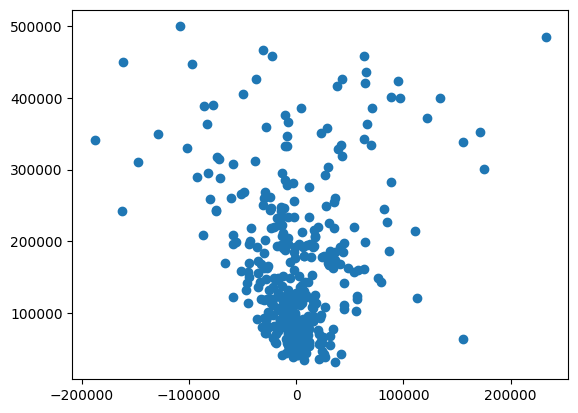

In [61]:
prop_val_2009_mod_resids = prop_val_2009_mod.resid
prop_val_2009_mod_fitted = prop_val_2009_mod.fittedvalues

plt.scatter(prop_val_2009_mod_resids, prop_val_2009_mod_fitted)

(array([  4.,   2.,  15.,  70., 197.,  57.,  13.,   4.,   4.,   1.]),
 array([-187784.03171822, -145734.52465599, -103685.01759377,
         -61635.51053155,  -19586.00346933,   22463.50359289,
          64513.01065511,  106562.51771734,  148612.02477956,
         190661.53184178,  232711.038904  ]),
 <BarContainer object of 10 artists>)

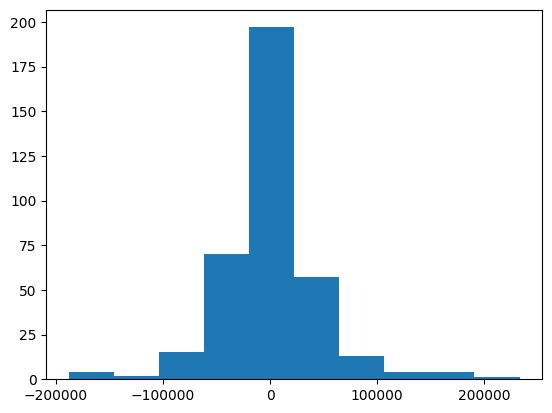

In [62]:
plt.hist(prop_val_2009_mod_resids)

In [57]:
inc_2009_mod = smf.ols("med_inc~ sum_breweries + prop_black+prop_asian+prop_hispanic_or_latino + med_prop_val + pct_bachelor_or_higher",
                 data=pq_tract_agg09).fit()

inc_2009_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                med_inc   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     88.00
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.55e-67
Time:                        10:35:47   Log-Likelihood:                -3957.7
No. Observations:                 367   AIC:                             7929.
Df Residuals:                     360   BIC:                             7957.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3.999e+04   2714.082     14.736      0.000    3.47e+04    4.53e+04
sum_breweries           -1924.5430   4385.940     -0.439      0.661   -1.05e+04    6700.740
prop_black              -1.774e+04   2521.244     -7.036      0.000   -2.27e+04   -1.28e+04
prop_asian              -2.124e+04   4334.827     -4.901      0.000   -2.98e+04   -1.27e+04
prop_hispanic_or_latino -2.882e+04   4584.447     -6.286      0.000   -3.78e+04   -1.98e+04
med_prop_val                0.0477      0.013      3.562      0.000       0.021       0.074
pct_bachelor_or_higher    190.2740     66.046      2.881      0.004      60.390     320.158
==============================================================================
Omnibus:                       32.797   Durbin-Watson:                   1.258
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.379
Skew:                          -0.068   Prob(JB):                     8.15e-34
Kurtosis:                       6.154   Cond. No.                     1.78e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.78e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
edu_2009_mod = smf.ols("pct_bachelor_or_higher~ sum_breweries + prop_black+prop_asian+prop_hispanic_or_latino + med_prop_val + med_inc",
                 data=pq_tract_agg09).fit()

edu_2009_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     pct_bachelor_or_higher   R-squared:                       0.811
Model:                                OLS   Adj. R-squared:                  0.807
Method:                     Least Squares   F-statistic:                     256.8
Date:                    Fri, 29 May 2026   Prob (F-statistic):          9.39e-127
Time:                            10:36:24   Log-Likelihood:                -1335.5
No. Observations:                     367   AIC:                             2685.
Df Residuals:                         360   BIC:                             2712.
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -9.6739      2.663     -3.633      0.000     -14.911      -4.437
sum_breweries              15.0909      3.369      4.480      0.000       8.466      21.716
prop_black                  5.1720      2.104      2.458      0.014       1.035       9.310
prop_asian                  1.6171      3.531      0.458      0.647      -5.327       8.561
prop_hispanic_or_latino     0.5635      3.810      0.148      0.883      -6.929       8.056
med_prop_val                0.0002   6.86e-06     22.877      0.000       0.000       0.000
med_inc                     0.0001   4.11e-05      2.881      0.004    3.76e-05       0.000
==============================================================================
Omnibus:                       89.190   Durbin-Watson:                   1.330
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              238.621
Skew:                           1.147   Prob(JB):                     1.53e-52
Kurtosis:                       6.216   Cond. No.                     2.04e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""